# Sound Module Training Notebook V1

This notebook is written for **Google Colab** and trains the first practical version of the **HDDS sound detection module**.

## Dataset Choice

This notebook uses exactly two datasets:

1. **DADS** (`geronimobasso/drone-audio-detection-samples`) as the main **drone-positive** source
2. **ESC-50** as the main **background / no-drone** source

## Why These Two

### DADS

DADS is currently the strongest practical public starting point for drone-sound detection because it is large, directly accessible from Hugging Face, and already structured for `drone` vs `no-drone` classification.

### ESC-50

ESC-50 is a strong public environmental-sound dataset that gives us diverse negative examples such as:

- wind
- rain
- birds
- helicopters
- engines
- urban sounds

That is useful because the real target is not just to detect drone sound, but to **avoid false alarms**.

## Main Training Strategy

This notebook trains a practical binary classifier:

- `1 = drone`
- `0 = no_drone`

The notebook includes:

1. dataset download into the **Colab session disk** (`/content`)
2. audio materialization to WAV files
3. feature extraction
4. baseline classical model training
5. stronger YAMNet-embedding model training
6. evaluation and export

## Important Constraint

This notebook avoids Google Drive. Everything is downloaded into the temporary Colab runtime storage.


## Outline

1. Install dependencies.
2. Create the Colab session workspace.
3. Download DADS metadata/audio samples into `/content`.
4. Download ESC-50 into `/content`.
5. Build a balanced binary dataset.
6. Extract MFCC-based baseline features.
7. Train a classical baseline model.
8. Extract YAMNet embeddings.
9. Train a stronger embedding-based model.
10. Evaluate, compare, and export artifacts.


In [1]:
# Colab dependency setup
!pip install -q datasets[audio] librosa soundfile scikit-learn pandas matplotlib seaborn tqdm tensorflow tensorflow-hub tensorflow-io joblib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 52.6 MB/s eta 0:00:00


In [2]:
# Optional: clone useful reference repositories
%cd /content
!git clone https://github.com/karolpiczak/ESC-50.git external_esc50


/content
Cloning into 'external_esc50'...
remote: Enumerating objects: 4199, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 4199 (delta 62), reused 34 (delta 34), pack-reused 4130 (from 1)
Receiving objects: 100% (4199/4199), 878.77 MiB | 14.58 MiB/s, done.
Resolving deltas: 100% (292/292), done.
Updating files: 100% (2011/2011), done.


In [3]:
from __future__ import annotations

import json
import os
import random
import shutil
from collections import Counter
from pathlib import Path

import joblib
import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import soundfile as sf
import tensorflow as tf
import tensorflow_hub as hub
from datasets import Audio, load_dataset
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

ROOT = Path('/content/hdds_audio')
RAW_ROOT = ROOT / 'raw'
WORK_ROOT = ROOT / 'work'
EXPORT_ROOT = ROOT / 'exports'
DADS_ROOT = RAW_ROOT / 'dads'
ESC50_ROOT = RAW_ROOT / 'esc50'
MANIFEST_ROOT = WORK_ROOT / 'manifests'
WAV_ROOT = WORK_ROOT / 'wav_data'

for folder in [RAW_ROOT, WORK_ROOT, EXPORT_ROOT, DADS_ROOT, ESC50_ROOT, MANIFEST_ROOT, WAV_ROOT]:
    folder.mkdir(parents=True, exist_ok=True)

print('Workspace root:', ROOT)
print('Raw root:', RAW_ROOT)
print('Export root:', EXPORT_ROOT)


Workspace root: /content/hdds_audio
Raw root: /content/hdds_audio/raw
Export root: /content/hdds_audio/exports


## Configuration

You can tune the amount of data downloaded into the Colab session.

Because DADS is large, this notebook defaults to a **controlled sampled subset** rather than downloading all positives immediately.

That is the correct Colab-first approach.


In [4]:
TARGET_SR = 16000
CLIP_DURATION_S = 3.0
TARGET_SAMPLES = int(TARGET_SR * CLIP_DURATION_S)

MAX_DRONE_CLIPS = 6000
MAX_BACKGROUND_CLIPS = 6000

# Start smaller if you want faster debugging.
# Example:
# MAX_DRONE_CLIPS = 1000
# MAX_BACKGROUND_CLIPS = 1000


## Download Dataset 1: DADS

DADS is loaded directly from Hugging Face.

Important practical choice:

- we only use **positive drone** examples from DADS in this notebook,
- because the second selected dataset, ESC-50, is our dedicated no-drone/background source.

This keeps dataset roles clean and makes ablation easier later.


In [5]:
# Load DADS in streaming mode to avoid pulling the full dataset blindly.
dads_stream = load_dataset(
    'geronimobasso/drone-audio-detection-samples',
    split='train',
    streaming=True,
)
print(dads_stream)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/39 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/39 [00:00<?, ?it/s]

IterableDataset({
    features: ['audio', 'label'],
    num_shards: 39
})


In [6]:
def save_fixed_length_wav(audio_array: np.ndarray, sr: int, out_path: Path, target_sr: int = TARGET_SR, duration_s: float = CLIP_DURATION_S):
    if sr != target_sr:
        audio_array = librosa.resample(audio_array, orig_sr=sr, target_sr=target_sr)
        sr = target_sr

    if audio_array.ndim > 1:
        audio_array = librosa.to_mono(audio_array.T)

    target_len = int(target_sr * duration_s)
    if len(audio_array) > target_len:
        audio_array = audio_array[:target_len]
    else:
        audio_array = np.pad(audio_array, (0, target_len - len(audio_array)))

    out_path.parent.mkdir(parents=True, exist_ok=True)
    sf.write(out_path, audio_array, target_sr)


def materialize_dads_positive_subset(max_clips: int) -> pd.DataFrame:
    rows = []
    save_dir = WAV_ROOT / 'dads_drone'
    save_dir.mkdir(parents=True, exist_ok=True)

    count = 0
    for example in tqdm(dads_stream, total=max_clips, desc='Streaming DADS drone positives'):
        if int(example['label']) != 1:
            continue

        audio = example['audio']
        out_path = save_dir / f'dads_drone_{count:06d}.wav'
        save_fixed_length_wav(audio['array'], audio['sampling_rate'], out_path)
        rows.append({
            'path': str(out_path),
            'label': 1,
            'source': 'DADS',
            'group': f'dads_{count:06d}',
        })
        count += 1
        if count >= max_clips:
            break

    df = pd.DataFrame(rows)
    manifest_path = MANIFEST_ROOT / 'dads_positive_manifest.csv'
    df.to_csv(manifest_path, index=False)
    print('Saved DADS positive manifest:', manifest_path)
    print('DADS positive clips:', len(df))
    return df


## Download Dataset 2: ESC-50

ESC-50 is downloaded directly from the official GitHub repository.

Why this is useful:

- no manual Drive step
- manageable size
- strong negative environmental diversity
- easy metadata access through `esc50.csv`


In [7]:
%cd /content
!rm -rf ESC-50
!git clone https://github.com/karolpiczak/ESC-50.git


/content
Cloning into 'ESC-50'...
remote: Enumerating objects: 4199, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 4199 (delta 62), reused 34 (delta 34), pack-reused 4130 (from 1)
Receiving objects: 100% (4199/4199), 878.77 MiB | 26.31 MiB/s, done.
Resolving deltas: 100% (292/292), done.
Updating files: 100% (2011/2011), done.


In [8]:
ESC50_REPO = Path('/content/ESC-50')
ESC50_AUDIO = ESC50_REPO / 'audio'
ESC50_META = ESC50_REPO / 'meta' / 'esc50.csv'

esc50_df = pd.read_csv(ESC50_META)
esc50_df.head()


,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


## ESC-50 Negative Policy

All ESC-50 clips are treated as `no_drone` negatives.

This includes hard confusing classes such as:

- helicopter
- engine
- airplane
- insects
- chainsaw
- wind

That is a good thing for the binary detector, because it makes the negative class harder and more realistic.


In [9]:
def materialize_esc50_negative_subset(max_clips: int) -> pd.DataFrame:
    rows = []
    save_dir = WAV_ROOT / 'esc50_background'
    save_dir.mkdir(parents=True, exist_ok=True)

    sampled = esc50_df.sample(n=min(max_clips, len(esc50_df)), random_state=SEED).reset_index(drop=True)

    for idx, row in tqdm(sampled.iterrows(), total=len(sampled), desc='Preparing ESC-50 negatives'):
        src = ESC50_AUDIO / row['filename']
        y, sr = librosa.load(src, sr=None, mono=True)
        out_path = save_dir / f'esc50_bg_{idx:06d}.wav'
        save_fixed_length_wav(y, sr, out_path)
        rows.append({
            'path': str(out_path),
            'label': 0,
            'source': 'ESC50',
            'group': f"esc50_fold_{row['fold']}",
            'category': row['category'],
        })

    df = pd.DataFrame(rows)
    manifest_path = MANIFEST_ROOT / 'esc50_negative_manifest.csv'
    df.to_csv(manifest_path, index=False)
    print('Saved ESC-50 negative manifest:', manifest_path)
    print('ESC-50 negative clips:', len(df))
    return df


## Build The Binary Dataset

The next two cells perform the actual session-disk downloads / materialization.

This is where the audio files are written into `/content/hdds_audio/work/wav_data`.


In [10]:
dads_df = materialize_dads_positive_subset(MAX_DRONE_CLIPS)


Streaming DADS drone positives:   0%|          | 0/6000 [00:00<?, ?it/s]

Saved DADS positive manifest: /content/hdds_audio/work/manifests/dads_positive_manifest.csv
DADS positive clips: 6000


In [11]:
esc50_neg_df = materialize_esc50_negative_subset(MAX_BACKGROUND_CLIPS)


Preparing ESC-50 negatives:   0%|          | 0/2000 [00:00<?, ?it/s]

Saved ESC-50 negative manifest: /content/hdds_audio/work/manifests/esc50_negative_manifest.csv
ESC-50 negative clips: 2000


In [12]:
dataset_df = pd.concat([dads_df, esc50_neg_df], ignore_index=True)
dataset_df = dataset_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

print(dataset_df['label'].value_counts())
print(dataset_df['source'].value_counts())
dataset_df.head()


label
1    6000
0    2000
Name: count, dtype: int64
source
DADS     6000
ESC50    2000
Name: count, dtype: int64


,path,label,source,group,category
0,/content/hdds_audio/work/wav_data/dads_drone/d...,1,DADS,dads_002215,NaN
1,/content/hdds_audio/work/wav_data/dads_drone/d...,1,DADS,dads_002582,NaN
2,/content/hdds_audio/work/wav_data/dads_drone/d...,1,DADS,dads_001662,NaN
3,/content/hdds_audio/work/wav_data/dads_drone/d...,1,DADS,dads_003027,NaN
4,/content/hdds_audio/work/wav_data/dads_drone/d...,1,DADS,dads_004343,NaN


## Train / Validation / Test Split

This notebook uses a simple stratified split for the first Colab baseline.

For a later research-grade version, cross-dataset evaluation should also be added.


In [13]:
train_df, temp_df = train_test_split(
    dataset_df,
    test_size=0.30,
    stratify=dataset_df['label'],
    random_state=SEED,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label'],
    random_state=SEED,
)

print('Train:', train_df.shape)
print('Val:', val_df.shape)
print('Test:', test_df.shape)


Train: (5600, 5)
Val: (1200, 5)
Test: (1200, 5)


## Baseline Features: MFCC + Spectral Features

This baseline is useful because:

1. it is fast,
2. interpretable,
3. and gives you a reference before using pretrained embeddings.


In [14]:
def extract_baseline_features(file_path: str) -> np.ndarray:
    y, sr = librosa.load(file_path, sr=TARGET_SR, mono=True)

    features = []
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    delta = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)

    for feat in [mfcc, delta, delta2]:
        features.extend(feat.mean(axis=1).tolist())
        features.extend(feat.std(axis=1).tolist())

    sc = librosa.feature.spectral_centroid(y=y, sr=sr)
    sb = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    zcr = librosa.feature.zero_crossing_rate(y)
    rms = librosa.feature.rms(y=y)
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr)

    features.extend([sc.mean(), sc.std()])
    features.extend([sb.mean(), sb.std()])
    features.extend([rolloff.mean(), rolloff.std()])
    features.extend([zcr.mean(), zcr.std()])
    features.extend([rms.mean(), rms.std()])
    features.extend(contrast.mean(axis=1).tolist())
    features.extend(contrast.std(axis=1).tolist())

    return np.asarray(features, dtype=np.float32)


def build_feature_matrix(df: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    X = []
    y = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc='Extracting baseline features'):
        X.append(extract_baseline_features(row['path']))
        y.append(int(row['label']))
    return np.asarray(X), np.asarray(y)


In [15]:
X_train_base, y_train = build_feature_matrix(train_df)
X_val_base, y_val = build_feature_matrix(val_df)
X_test_base, y_test = build_feature_matrix(test_df)

print(X_train_base.shape, X_val_base.shape, X_test_base.shape)


Extracting baseline features:   0%|          | 0/5600 [00:00<?, ?it/s]

Extracting baseline features:   0%|          | 0/1200 [00:00<?, ?it/s]

Extracting baseline features:   0%|          | 0/1200 [00:00<?, ?it/s]

(5600, 264) (1200, 264) (1200, 264)


## Baseline Model Training

This baseline uses:

- `StandardScaler`
- `LogisticRegression`

You can later compare it against:

- histogram gradient boosting
- random forest
- XGBoost

But logistic regression is a good first sanity check.


In [16]:
baseline_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=2000, random_state=SEED)),
])

baseline_model.fit(X_train_base, y_train)
val_pred_base = baseline_model.predict(X_val_base)
print(classification_report(y_val, val_pred_base, target_names=['no_drone', 'drone']))


              precision    recall  f1-score   support

    no_drone       1.00      1.00      1.00       300
       drone       1.00      1.00      1.00       900

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200



## Stronger Model: YAMNet Embeddings

The stronger Colab-friendly model in this notebook is:

- pretrained **YAMNet** embeddings
- followed by a small classical classifier

This is a good engineering choice because:

1. it is much stronger than handcrafted features alone,
2. it does not require heavy end-to-end training,
3. and it works well in Colab.


In [17]:
yamnet_model = hub.load('https://tfhub.dev/google/yamnet/1')
print('YAMNet loaded')


YAMNet loaded


In [18]:
def extract_yamnet_embedding(file_path: str) -> np.ndarray:
    y, sr = librosa.load(file_path, sr=16000, mono=True)
    waveform = tf.convert_to_tensor(y, dtype=tf.float32)
    scores, embeddings, spectrogram = yamnet_model(waveform)
    return tf.reduce_mean(embeddings, axis=0).numpy().astype(np.float32)


def build_embedding_matrix(df: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    X = []
    y = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc='Extracting YAMNet embeddings'):
        X.append(extract_yamnet_embedding(row['path']))
        y.append(int(row['label']))
    return np.asarray(X), np.asarray(y)


In [19]:
X_train_emb, _ = build_embedding_matrix(train_df)
X_val_emb, _ = build_embedding_matrix(val_df)
X_test_emb, _ = build_embedding_matrix(test_df)

print(X_train_emb.shape, X_val_emb.shape, X_test_emb.shape)


Extracting YAMNet embeddings:   0%|          | 0/5600 [00:00<?, ?it/s]

Extracting YAMNet embeddings:   0%|          | 0/1200 [00:00<?, ?it/s]

Extracting YAMNet embeddings:   0%|          | 0/1200 [00:00<?, ?it/s]

(5600, 1024) (1200, 1024) (1200, 1024)


In [20]:
yamnet_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', HistGradientBoostingClassifier(random_state=SEED)),
])

yamnet_clf.fit(X_train_emb, y_train)
val_pred_yamnet = yamnet_clf.predict(X_val_emb)
print(classification_report(y_val, val_pred_yamnet, target_names=['no_drone', 'drone']))


              precision    recall  f1-score   support

    no_drone       1.00      1.00      1.00       300
       drone       1.00      1.00      1.00       900

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200



## Final Test Evaluation

The next cell compares the baseline and the stronger embedding-based model on the held-out test set.


In [21]:
test_pred_base = baseline_model.predict(X_test_base)
test_pred_yamnet = yamnet_clf.predict(X_test_emb)

print('Baseline MFCC model')
print(classification_report(y_test, test_pred_base, target_names=['no_drone', 'drone']))

print('YAMNet embedding model')
print(classification_report(y_test, test_pred_yamnet, target_names=['no_drone', 'drone']))


Baseline MFCC model
              precision    recall  f1-score   support

    no_drone       1.00      1.00      1.00       300
       drone       1.00      1.00      1.00       900

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200

YAMNet embedding model
              precision    recall  f1-score   support

    no_drone       1.00      1.00      1.00       300
       drone       1.00      1.00      1.00       900

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200



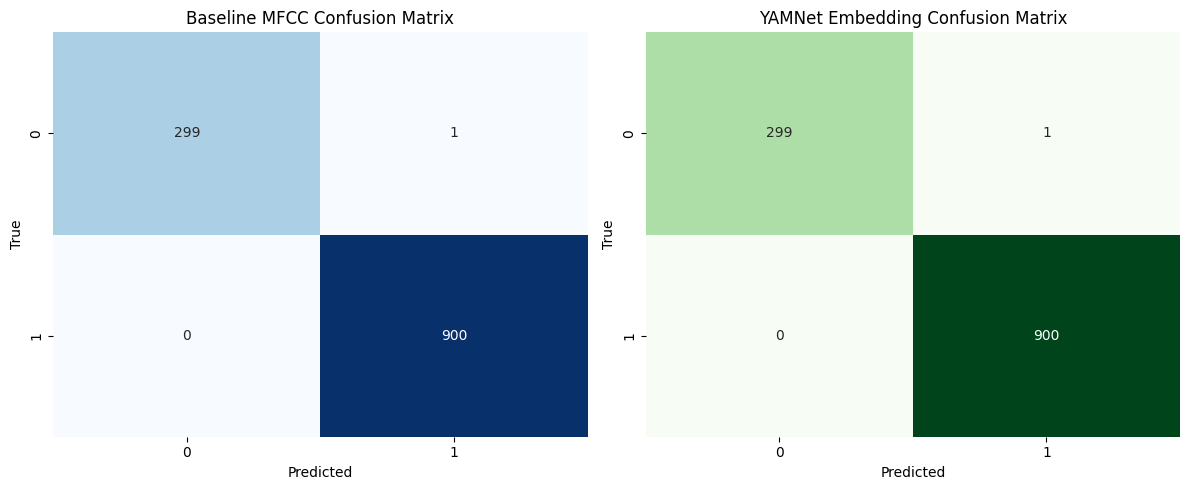

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_base = confusion_matrix(y_test, test_pred_base)
cm_yam = confusion_matrix(y_test, test_pred_yamnet)

sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Baseline MFCC Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(cm_yam, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('YAMNet Embedding Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()


## Export Artifacts

The notebook exports:

1. the baseline feature model,
2. the stronger YAMNet-based classifier,
3. the train/val/test manifests.

These are enough to start building the `audio/` package in `Project v1`.


In [23]:
EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

joblib.dump(baseline_model, EXPORT_ROOT / 'sound_baseline_mfcc_logreg.joblib')
joblib.dump(yamnet_clf, EXPORT_ROOT / 'sound_yamnet_hgb.joblib')

train_df.to_csv(EXPORT_ROOT / 'train_manifest.csv', index=False)
val_df.to_csv(EXPORT_ROOT / 'val_manifest.csv', index=False)
test_df.to_csv(EXPORT_ROOT / 'test_manifest.csv', index=False)

print('Exported files:')
for p in sorted(EXPORT_ROOT.iterdir()):
    print('-', p.name)


Exported files:
- sound_baseline_mfcc_logreg.joblib
- sound_yamnet_hgb.joblib
- test_manifest.csv
- train_manifest.csv
- val_manifest.csv


## What To Watch Carefully

1. **Class balance**  
   If DADS positives greatly outnumber ESC-50 negatives or vice versa, your reported accuracy can mislead you.

2. **Cross-dataset realism**  
   ESC-50 is useful, but it is not a dedicated anti-drone background dataset. It is a strong public negative source, not the final answer.

3. **False alarms on bird/insect/helicopter-like sounds**  
   These are exactly the kinds of sounds you should inspect manually later.

4. **DADS scale**  
   The full dataset is large. This notebook deliberately starts with a subset that is realistic for Colab.


## Recommended Next Step

After this notebook works, the next engineering move is:

1. build a standalone `audio/` package in `Project v1`,
2. turn the YAMNet-based path into an inference module,
3. expose per-window confidence scores,
4. and feed those scores into the future fusion layer.
